# Parcial – EDA, ETL y Aplicación en Plataformas No-Code

**Estudiante:** Mariana Gutierrez  
**Curso:** Ingeniería de Datos  

---

# 1. Selección del Dataset

**Nombre del dataset:** Mental Health & Productivity 2026

**Fuente:** https://www.kaggle.com/datasets/shadab80k/mental-health-productivity-2026

**Descripción del dataset**

Este dataset contiene información relacionada con la salud mental de empleados y su impacto en la productividad laboral.  
Incluye variables relacionadas con niveles de estrés, riesgo de agotamiento laboral (burnout), horas de trabajo, productividad y otros factores que pueden afectar el rendimiento en el trabajo.  
El dataset permite analizar patrones entre bienestar mental y desempeño laboral, facilitando estudios sobre ambientes laborales saludables.

**Tipo de datos presentes**

El dataset contiene principalmente:

- Variables numéricas (horas de trabajo, niveles de estrés, productividad)
- Variables categóricas (niveles de burnout, trabajo fuera de horario, etc.)
- Variables discretas relacionadas con hábitos laborales



## Descripción de las Variables del Dataset

| Variable                       | Tipo de Dato | Descripción                                                                   |
| :----------------------------- | :----------- | :---------------------------------------------------------------------------- |
| `Employee_ID`                  | object       | Identificador único del empleado.                                             |
| `Age`                          | int64        | Edad del empleado.                                                            |
| `Gender`                       | object       | Género del empleado.                                                          |
| `Country`                      | object       | País de residencia del empleado.                                              |
| `Industry`                     | object       | Industria en la que trabaja el empleado.                                      |
| `Work_Mode`                    | object       | Modalidad de trabajo (e.g., Remote, On-site, Hybrid).                         |
| `Work_Hours_Per_Week`          | int64        | Horas trabajadas por semana.                                                  |
| `Stress_Level`                 | int64        | Nivel de estrés del empleado (escala del 1 al 10).                           |
| `Sleep_Hours`                  | float64      | Horas de sueño promedio por día.                                              |
| `Productivity_Score`           | int64        | Puntuación de productividad del empleado (escala del 0 al 100).               |
| `Physical_Activity_Hours`      | float64      | Horas de actividad física por semana.                                         |
| `Mental_Health_Support_Access` | object       | Indica si el empleado tiene acceso a apoyo de salud mental (Yes/No).          |
| `Burnout_Risk`                 | object       | Nivel de riesgo de agotamiento laboral (e.g., Low, Medium, High).             |
| `productivity_level`           | category     | Nivel de productividad categorizado (Baja, Media, Alta).                      |

# 2. Proceso ETL

## Extracción

El dataset contiene información relacionada con la salud mental de trabajadores y diferentes factores asociados a su productividad.  
Las variables permiten analizar cómo aspectos como el estrés, el sueño y las horas trabajadas que influyen en el rendimiento laboral.  

En esta sección se realiza la extracción del dataset, su limpieza y transformación, y finalmente se guarda un dataset limpio listo para análisis.

# *Importar librerias*

In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Descarga desde Kaggle
import kagglehub

# Manejo del sistema operativo
import os

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
# Descargar la última versión"yadavhim/housing-csv"

path = kagglehub.dataset_download("shadab80k/mental-health-productivity-2026")

# Cargar el fichero que se llama: tested.csv

df = pd.read_csv(path + "/mental_health_productivity_2026.csv")




Using Colab cache for faster access to the 'mental-health-productivity-2026' dataset.


# Transformación

In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Country,0
Industry,0
Work_Mode,0
Work_Hours_Per_Week,0
Stress_Level,0
Sleep_Hours,0
Productivity_Score,0


In [ ]:
# Devuelve un DataFrame del mismo tamaño que df, pero en lugar de los valores originales, contiene True en cada posición donde el valor es nulo (NaN) y False donde el valor está presente.
df.isnull()


,Employee_ID,Age,Gender,Country,Industry,Work_Mode,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours,Mental_Health_Support_Access,Burnout_Risk
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,False,False,False,False,False,False,False,False,False,False,False,False,False
1496,False,False,False,False,False,False,False,False,False,False,False,False,False
1497,False,False,False,False,False,False,False,False,False,False,False,False,False
1498,False,False,False,False,False,False,False,False,False,False,False,False,False


Se realizó una verificación de valores faltantes para identificar posibles problemas de calidad en los datos que puedan afectar el análisis posterior.

# Tratamiento de valores faltantes

In [ ]:
df = df.dropna()

Se eliminaron las filas con valores faltantes para asegurar que el análisis se realice únicamente con datos completos.

# Conversión de tipos de datos

In [ ]:
df.dtypes

,0
Employee_ID,object
Age,int64
Gender,object
Country,object
Industry,object
Work_Mode,object
Work_Hours_Per_Week,int64
Stress_Level,int64
Sleep_Hours,float64
Productivity_Score,int64


Se revisaron los tipos de datos de cada variable para asegurar que las variables numéricas y categóricas estén correctamente clasificadas.

# Creación de nueva variable derivada

In [ ]:
df["productivity_level"] = pd.cut(
    df["Productivity_Score"],
    bins=[0,40,70,100],
    labels=["Baja","Media","Alta"]
)

Se creó una nueva variable llamada **productivity_level** que clasifica la productividad en tres niveles (Baja, Media y Alta) para facilitar el análisis y la interpretación de los resultados.

# Cargar

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

El dataset limpio fue guardado como **cleaned_dataset.csv**.  
Este archivo es más adecuado para análisis y modelado porque contiene datos consistentes, sin valores faltantes y con nuevas variables derivadas que facilitan la interpretación.

# Análisis Exploratorio de Datos (EDA)

# Vista inicial

In [ ]:
# DataFrame cabecera
df.head()


,Employee_ID,Age,Gender,Country,Industry,Work_Mode,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours,Mental_Health_Support_Access,Burnout_Risk
0,EMP_0001,50,Male,USA,Manufacturing,Remote,40,9,7.377341,89,6.564715,Yes,High
1,EMP_0002,36,Male,UK,Finance,Remote,35,1,6.186889,61,0.184572,Yes,Low
2,EMP_0003,29,Male,Brazil,Finance,Remote,52,4,7.474883,47,8.318881,No,Low
3,EMP_0004,42,Female,UK,Manufacturing,Remote,56,10,7.169386,49,1.746996,No,High
4,EMP_0005,40,Male,Germany,Tech,On-site,35,2,9.518479,53,5.154975,Yes,Low


Se observan las primeras filas del dataset para entender la estructura de los datos y verificar que las variables se hayan cargado correctamente.

# Información del dataset

In [ ]:
# Información del Dataset
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee_ID                   1500 non-null   object 
 1   Age                           1500 non-null   int64  
 2   Gender                        1500 non-null   object 
 3   Country                       1500 non-null   object 
 4   Industry                      1500 non-null   object 
 5   Work_Mode                     1500 non-null   object 
 6   Work_Hours_Per_Week           1500 non-null   int64  
 7   Stress_Level                  1500 non-null   int64  
 8   Sleep_Hours                   1500 non-null   float64
 9   Productivity_Score            1500 non-null   int64  
 10  Physical_Activity_Hours       1500 non-null   float64
 11  Mental_Health_Support_Access  1500 non-null   object 
 12  Burnout_Risk                  1500 non-null   object 
dtypes: 

La función muestra el número de registros, las columnas y los tipos de datos presentes en el dataset.

# Estadísticas descriptivas

In [ ]:
# Describir el dataset
df.describe()


,Age,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,41.002667,46.980000,6.244667,6.972800,69.837333,5.005239
std,11.062681,10.042252,2.987544,1.215902,17.397260,2.898687
min,22.000000,30.000000,1.000000,4.000000,40.000000,0.010870
25%,31.000000,38.000000,4.000000,6.137665,55.000000,2.525866
50%,42.000000,47.000000,7.000000,6.981871,70.000000,5.022898
75%,50.000000,55.250000,9.000000,7.818334,84.000000,7.525873
max,59.000000,64.000000,10.000000,10.000000,100.000000,9.996356


Las estadísticas descriptivas permiten observar medidas como la media, desviación estándar, valores mínimos y máximos de las variables numéricas.

# Dimensión del Dataset

In [ ]:
# Orden del Dataset
df.shape

(1500, 13)

La función muestra la dimensión del dataset, indicando el número de filas (registros) y columnas (variables) que contiene el DataFrame.

# Últimas filas del DataFrame

In [ ]:
# Mostrar las ultimas 5 filas
df.tail()

,Employee_ID,Age,Gender,Country,Industry,Work_Mode,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours,Mental_Health_Support_Access,Burnout_Risk
1495,EMP_1496,39,Non-binary,USA,Education,Remote,48,10,6.048564,76,0.391505,No,High
1496,EMP_1497,52,Non-binary,Germany,Manufacturing,Hybrid,60,10,7.916126,75,9.359731,No,High
1497,EMP_1498,59,Female,Germany,Manufacturing,Hybrid,55,4,8.409026,54,0.950651,Yes,Low
1498,EMP_1499,53,Male,Australia,Finance,Remote,52,10,7.574236,97,6.740230,Yes,High
1499,EMP_1500,32,Male,Australia,Retail,Remote,42,2,5.266123,59,1.333966,No,Low


La función muestra las últimas 5 filas del dataset. Esto permite verificar los datos al final del DataFrame y confirmar que la información se cargó correctamente.

# Histograma

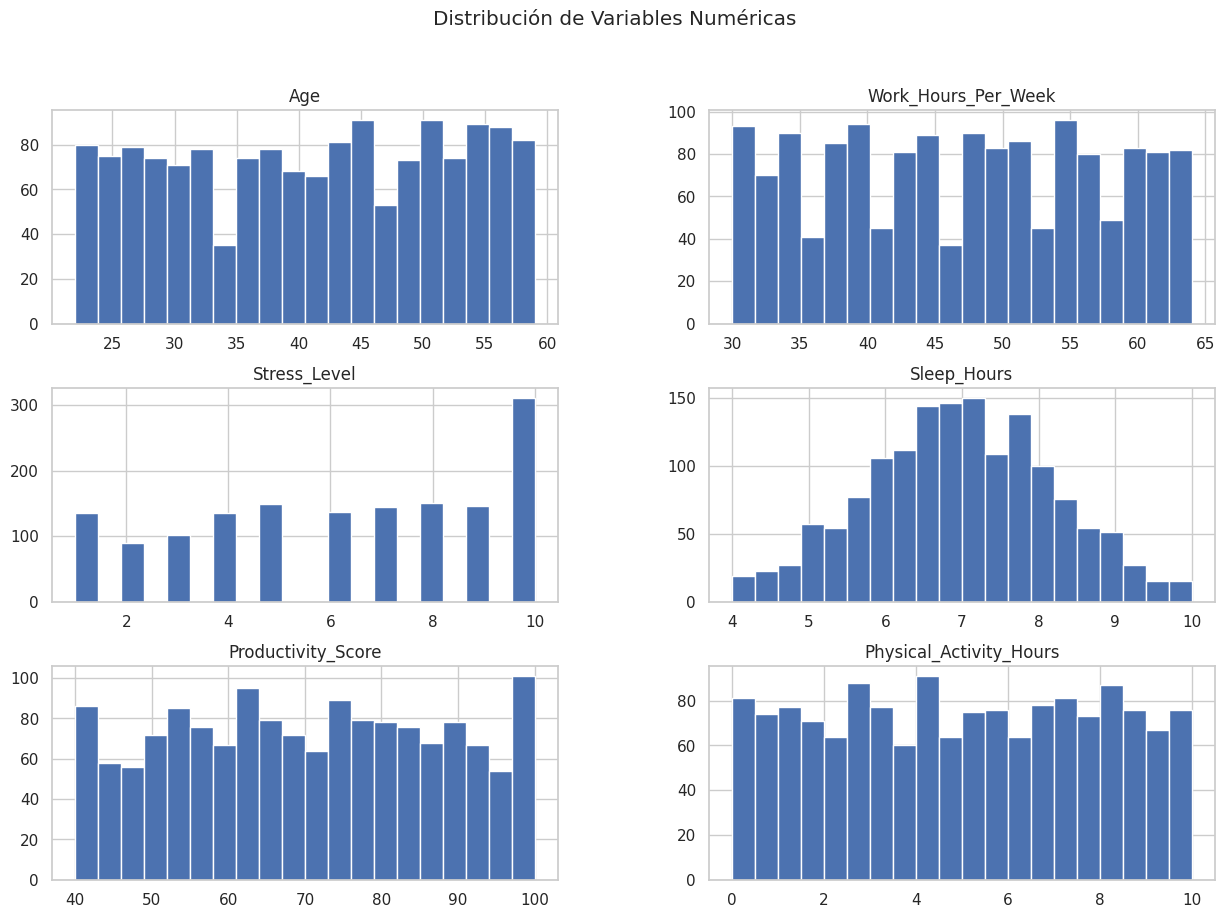

In [ ]:
df.hist(bins=20, figsize=(15,10))
plt.suptitle("Distribución de Variables Numéricas")
plt.show()

Los histogramas permiten visualizar la distribución de las variables numéricas y detectar posibles sesgos o concentraciones de valores.

# Diagrama de dispersión

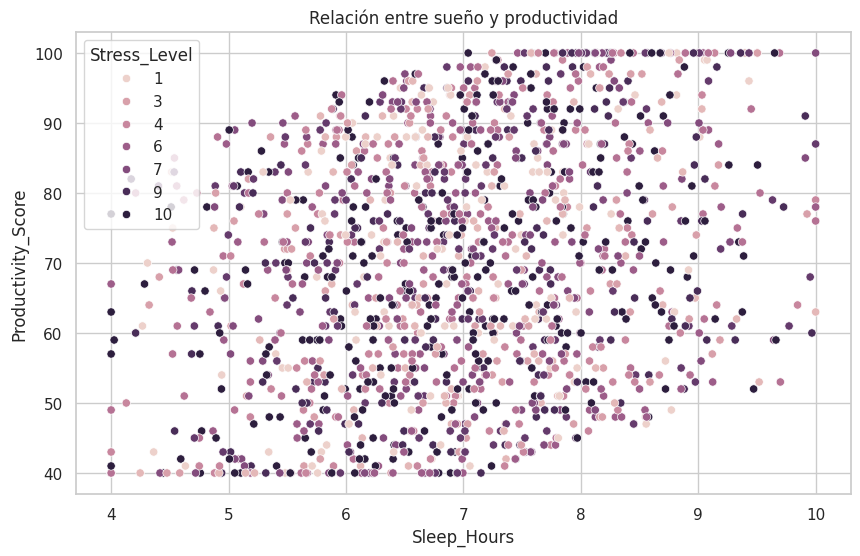

In [ ]:
sns.scatterplot(
    data=df,
    x="Sleep_Hours",
    y="Productivity_Score",
    hue="Stress_Level"
)

plt.title("Relación entre sueño y productividad")
plt.show()

El gráfico muestra la relación entre las horas de sueño y la productividad. También permite observar cómo el nivel de estrés puede influir en esta relación.

# Boxplot

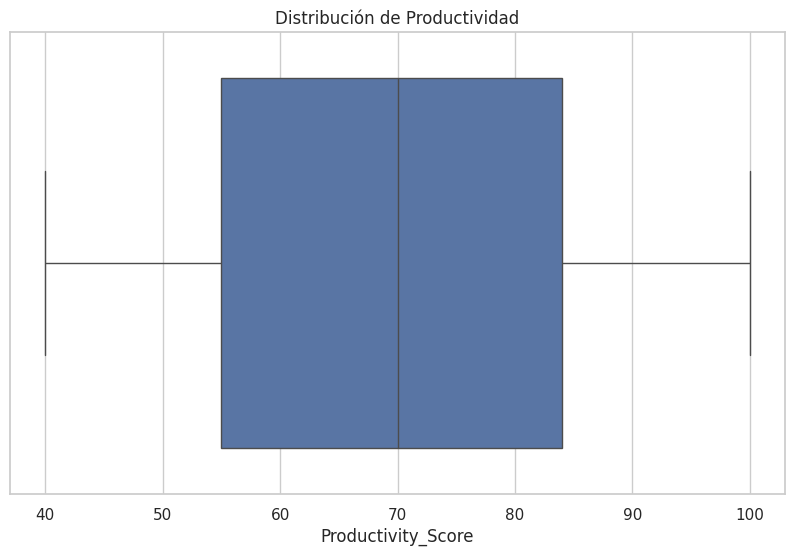

In [ ]:
sns.boxplot(x=df["Productivity_Score"])
plt.title("Distribución de Productividad")
plt.show()

El diagrama de caja permite identificar la dispersión de la productividad y detectar posibles valores atípicos en los datos.

# Matriz de correlación

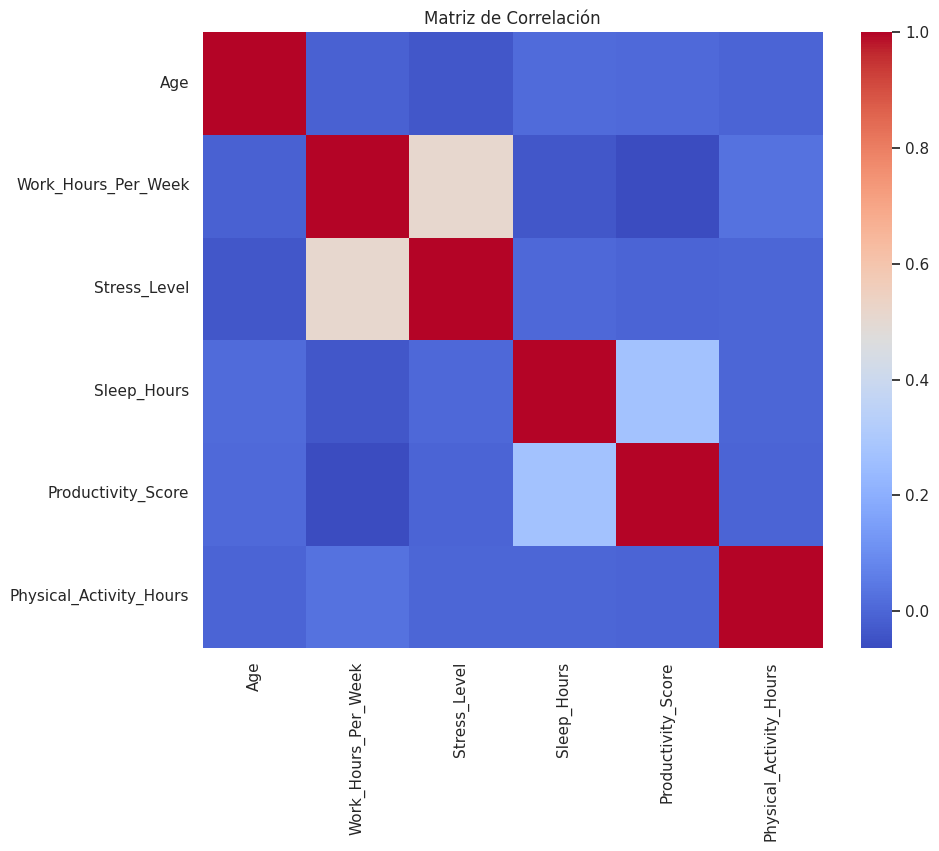

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Matriz de Correlación")
plt.show()

La matriz de correlación permite identificar relaciones entre variables numéricas y detectar posibles factores asociados con la productividad.

# Graficos

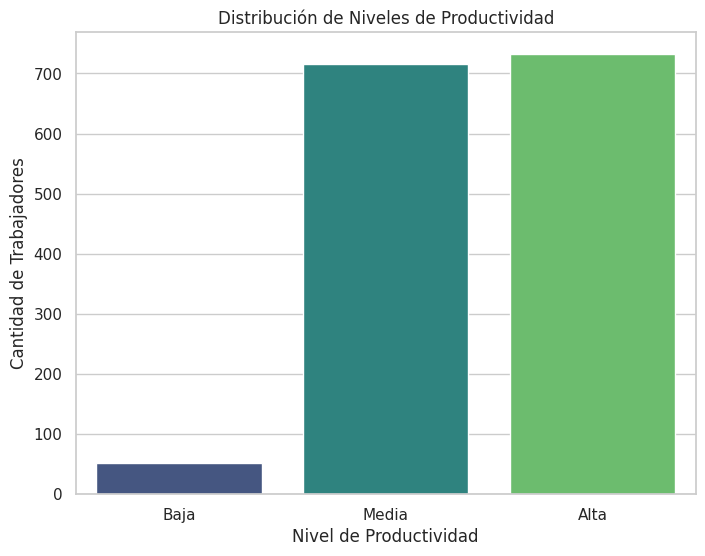

In [ ]:
plt.figure(figsize=(8,6))

sns.countplot(
    x="productivity_level",
    data=df,
    palette="viridis",
    hue="productivity_level",
    legend=False
)

plt.title("Distribución de Niveles de Productividad")
plt.xlabel("Nivel de Productividad")
plt.ylabel("Cantidad de Trabajadores")

plt.show()

El gráfico de barras muestra cuántos trabajadores pertenecen a cada nivel de productividad.
Esto permite identificar si la mayoría de los empleados se concentran en niveles bajos, medios o altos de productividad.

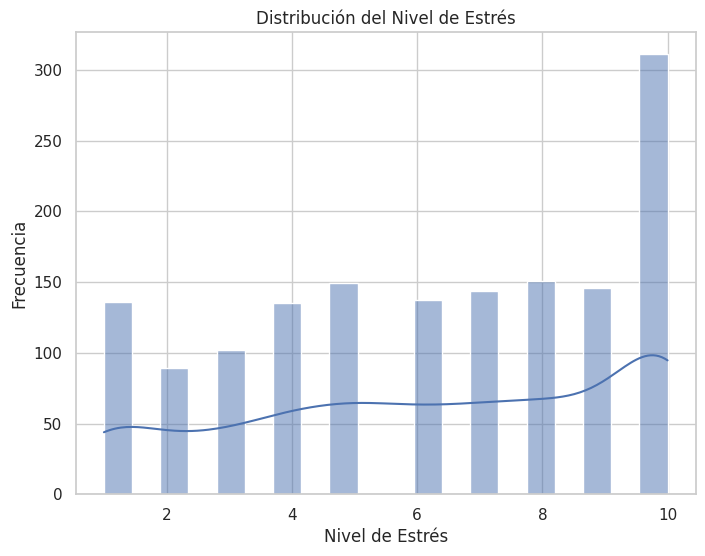

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["Stress_Level"],
    bins=20,
    kde=True
)

plt.title("Distribución del Nivel de Estrés")
plt.xlabel("Nivel de Estrés")
plt.ylabel("Frecuencia")

plt.show()

El histograma permite analizar cómo se distribuyen los niveles de estrés entre los trabajadores.
También ayuda a identificar si existen concentraciones de estrés en ciertos rangos.

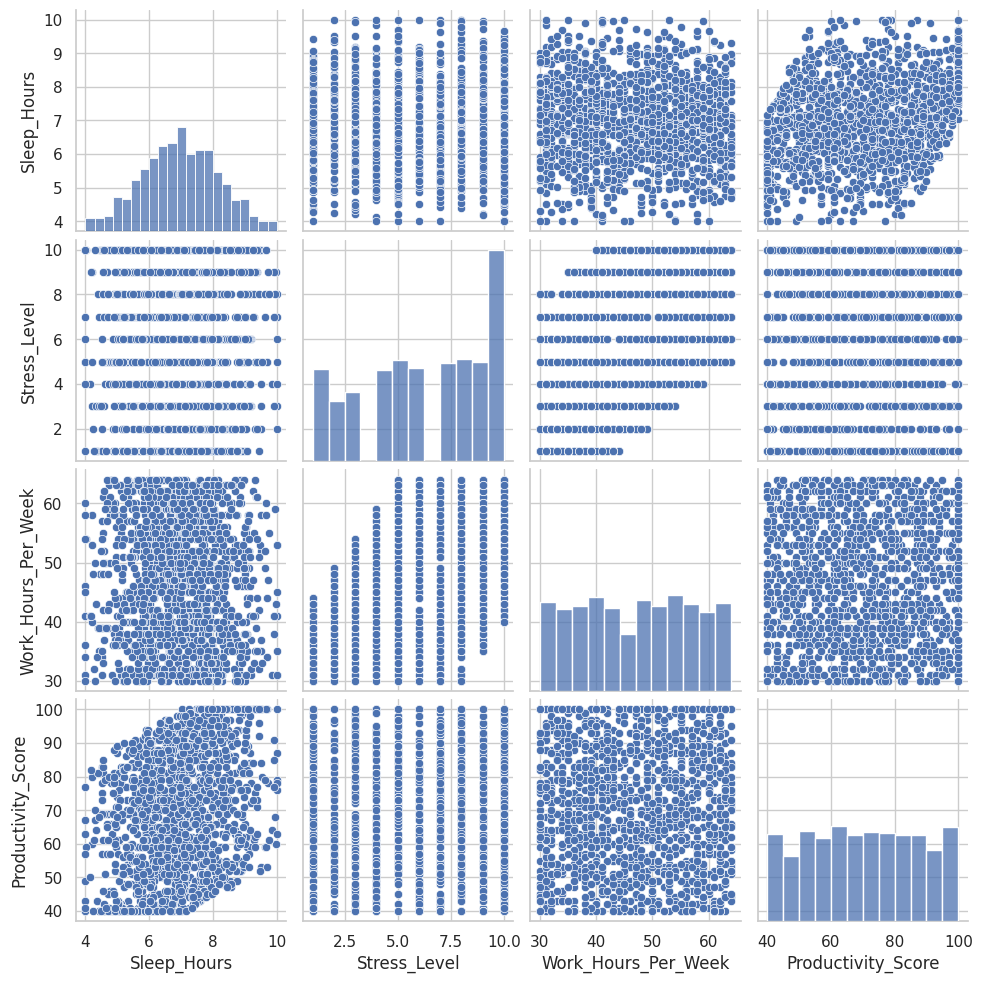

In [ ]:
sns.pairplot(
    df[['Sleep_Hours','Stress_Level','Work_Hours_Per_Week','Productivity_Score']],
    diag_kind='hist'
)

plt.show()

Este gráfico permite visualizar las relaciones entre varias variables numéricas al mismo tiempo.
Se pueden observar posibles correlaciones entre horas de sueño, nivel de estrés, horas trabajadas y productividad.

# Hallazgos



1. Se observa que mayores niveles de estrés tienden a estar asociados con menores niveles de productividad.
2. Las personas con más horas de sueño muestran en promedio mejores niveles de rendimiento laboral.
3. Existe variabilidad significativa en la productividad entre los trabajadores, lo que puede estar relacionado con factores de bienestar mental.

# Aplicación en Plataforma No-Code



El dataset limpio podría utilizarse para crear una aplicación en AppSheet enfocada en el monitoreo del bienestar laboral y la productividad de los empleados.

La aplicación podría mostrar indicadores como niveles de estrés, horas de sueño y productividad de cada trabajador. También podría incluir formularios para registrar información periódica sobre bienestar mental y desempeño laboral.

Las visualizaciones dentro de la aplicación permitirían a los gerentes identificar patrones o problemas relacionados con la salud mental en el equipo de trabajo. Esto facilitaría la toma de decisiones orientadas a mejorar el ambiente laboral y aumentar la productividad.

Además, la aplicación podría generar reportes automáticos que ayuden a los responsables de recursos humanos a implementar estrategias de bienestar organizacional.